In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content'
!kaggle datasets download diversisai/fire-segmentation-image-dataset

!unzip fire-segmentation-image-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Segmentation_Mask/Fire/Img_5374.jpg  
  inflating: Segmentation_Mask/Fire/Img_5375.jpg  
  inflating: Segmentation_Mask/Fire/Img_5376.jpg  
  inflating: Segmentation_Mask/Fire/Img_5377.jpg  
  inflating: Segmentation_Mask/Fire/Img_5378.jpg  
  inflating: Segmentation_Mask/Fire/Img_5379.jpg  
  inflating: Segmentation_Mask/Fire/Img_538.jpg  
  inflating: Segmentation_Mask/Fire/Img_5380.jpg  
  inflating: Segmentation_Mask/Fire/Img_5381.jpg  
  inflating: Segmentation_Mask/Fire/Img_5382.jpg  
  inflating: Segmentation_Mask/Fire/Img_5383.jpg  
  inflating: Segmentation_Mask/Fire/Img_5384.jpg  
  inflating: Segmentation_Mask/Fire/Img_5385.jpg  
  inflating: Segmentation_Mask/Fire/Img_5386.jpg  
  inflating: Segmentation_Mask/Fire/Img_5387.jpg  
  inflating: Segmentation_Mask/Fire/Img_5388.jpg  
  inflating: Segmentation_Mask/Fire/Img_5389.jpg  
  inflating: Segmentation_Mask/Fire/Img_539.jpg  
  inflating: Segmentation_Mask/Fi

In [ ]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

In [ ]:
dataset_path = "/content"
fire_img_dir = os.path.join(dataset_path, "Image", "Fire")
nofire_img_dir = os.path.join(dataset_path, "Image", "Not_Fire")
mask_dir = os.path.join(dataset_path, "Segmentation_Mask", "Fire")

In [ ]:
image_paths = []
mask_paths = []

# Fire images
for img in sorted(glob(fire_img_dir + "/*")):

    filename = os.path.basename(img)

    mask = os.path.join(mask_dir, filename)

    if os.path.exists(mask):
        image_paths.append(img)
        mask_paths.append(mask)

# Non-fire images
for img in sorted(glob(nofire_img_dir + "/*")):

    image_paths.append(img)
    mask_paths.append(None)

print("Total images:", len(image_paths))

Total images: 38852


In [ ]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

In [ ]:
train_transform = A.Compose([
    A.Resize(256,256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=20,p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256,256),
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
class FireDataset(Dataset):

    def __init__(self, images, masks, transform=None):

        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.masks[idx] is None:

            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        else:

            mask = cv2.imread(self.masks[idx], 0)

        mask = (mask > 127).astype(np.float32)

        if self.transform:

            aug = self.transform(image=image, mask=mask)

            image = aug["image"]
            mask = aug["mask"]

        mask = mask.unsqueeze(0)

        return image, mask

In [ ]:
train_dataset = FireDataset(
    train_imgs,
    train_masks,
    train_transform
)

val_dataset = FireDataset(
    val_imgs,
    val_masks,
    val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

In [ ]:
loss_fn = smp.losses.DiceLoss(mode='binary')

bce = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
def iou_score(pred, mask):

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

    intersection = (pred * mask).sum()

    union = pred.sum() + mask.sum() - intersection

    return (intersection + 1e-6)/(union + 1e-6)

In [ ]:
num_epochs = 10

best_loss = 1e10

for epoch in range(num_epochs):

    model.train()

    train_loss = 0

    train_iou = 0

    for images, masks in tqdm(train_loader):

        images = images.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, masks)

        loss += bce(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        train_iou += iou_score(outputs, masks).item()

    train_loss /= len(train_loader)

    train_iou /= len(train_loader)

    model.eval()

    val_loss = 0

    val_iou = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)

            masks = masks.to(device)

            outputs = model(images)

            loss = loss_fn(outputs, masks)

            loss += bce(outputs, masks)

            val_loss += loss.item()

            val_iou += iou_score(outputs, masks).item()

    val_loss /= len(val_loader)

    val_iou /= len(val_loader)

    print(f"Epoch {epoch+1}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train IoU  : {train_iou:.4f}")

    print(f"Val IoU    : {val_iou:.4f}")

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(model.state_dict(), "best_unet_fire.pth")

        print("Model Saved")

100%|██████████| 972/972 [07:11<00:00,  2.25it/s]


Epoch 1
Train Loss : 0.7524
Val Loss   : 0.3739
Train IoU  : 0.3957
Val IoU    : 0.5488
Model Saved


100%|██████████| 972/972 [07:25<00:00,  2.18it/s]


Epoch 2
Train Loss : 0.3503
Val Loss   : 0.2884
Train IoU  : 0.5471
Val IoU    : 0.6036
Model Saved


100%|██████████| 972/972 [07:25<00:00,  2.18it/s]


...

Epoch 8
Train Loss : 0.2258
Val Loss   : 0.2014
Train IoU  : 0.6692
Val IoU    : 0.6997
Model Saved


100%|██████████| 972/972 [07:25<00:00,  2.18it/s]


Epoch 9
Train Loss : 0.2168
Val Loss   : 0.1973
Train IoU  : 0.6801
Val IoU    : 0.7046
Model Saved


100%|██████████| 972/972 [07:25<00:00,  2.18it/s]


Epoch 10
Train Loss : 0.2123
Val Loss   : 0.1901
Train IoU  : 0.6857
Val IoU    : 0.7137
Model Saved


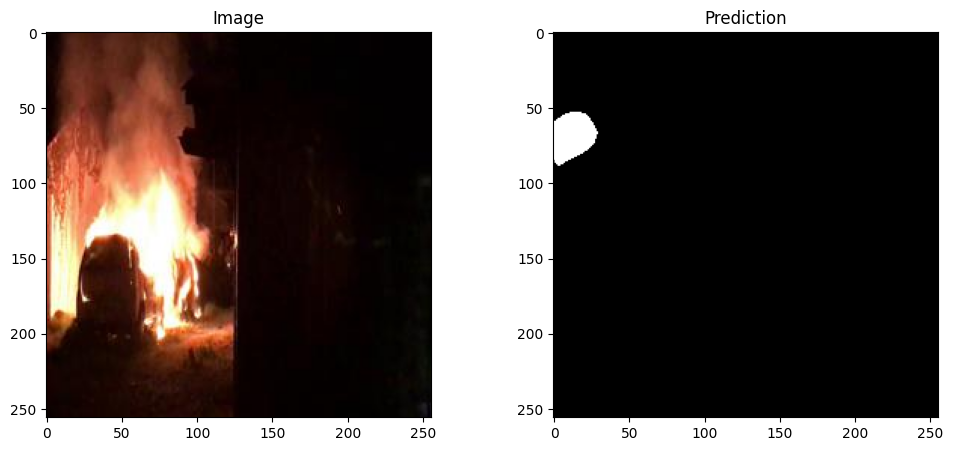

In [ ]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_unet_fire.pth"))

model.eval()

image_path = val_imgs[0]

image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

transform = A.Compose([
    A.Resize(256,256),
    A.Normalize(),
    ToTensorV2()
])

aug = transform(image=image)

input_image = aug["image"].unsqueeze(0).to(device)

with torch.no_grad():

    pred = model(input_image)

pred = torch.sigmoid(pred)

pred = pred.squeeze().cpu().numpy()

pred = pred > 0.5

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")

plt.show()

In [1]:
from google.colab import files

files.download('FireSegmentation.ipynb')

FileNotFoundError: Cannot find file: FireSegmentation.ipynb

In [ ]:
torch.save(model.state_dict(), 'best_unet_fire.pth')
print("Trained Model Saved")

NameError: name 'torch' is not defined

In [ ]:
from google.colab import files
files.download('best_unet_fire.pth')

FileNotFoundError: Cannot find file: best_unet_fire.pth